In [ ]:
!pip install kagglehub

In [ ]:
import kagglehub

# Download dataset
path = kagglehub.dataset_download("jessicali9530/celeba-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'celeba-dataset' dataset.
Path to dataset files: /kaggle/input/celeba-dataset


In [ ]:
import os
os.listdir(path)

['list_landmarks_align_celeba.csv',
 'img_align_celeba',
 'list_eval_partition.csv',
 'list_attr_celeba.csv',
 'list_bbox_celeba.csv']

In [ ]:
import tensorflow as tf

IMG_SIZE = 64
BATCH_SIZE = 64

img_dir = os.path.join(path, "img_align_celeba", "img_align_celeba")

dataset = tf.keras.utils.image_dataset_from_directory(
    img_dir,
    label_mode=None,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    shuffle=True
)

dataset = dataset.map(lambda x: tf.cast(x, tf.float32) / 255.0)
dataset = dataset.take(500)
dataset = dataset.prefetch(tf.data.AUTOTUNE)

Found 202599 files.


In [ ]:
from tensorflow.keras import layers

class Sampling(layers.Layer):
    def call(self, inputs):
        z_mean, z_log_var = inputs
        epsilon = tf.random.normal(shape=tf.shape(z_mean))
        return z_mean + tf.exp(0.5 * z_log_var) * epsilon

In [ ]:
from tensorflow.keras import models

LATENT_DIM = 128

encoder_inputs = layers.Input(shape=(64,64,3))
x = layers.Conv2D(32,3,strides=2,padding="same",activation="relu")(encoder_inputs)
x = layers.Conv2D(64,3,strides=2,padding="same",activation="relu")(x)
x = layers.Conv2D(128,3,strides=2,padding="same",activation="relu")(x)
x = layers.Flatten()(x)
x = layers.Dense(512,activation="relu")(x)

z_mean = layers.Dense(LATENT_DIM)(x)
z_log_var = layers.Dense(LATENT_DIM)(x)

z = Sampling()([z_mean,z_log_var])

encoder = models.Model(encoder_inputs,[z_mean,z_log_var,z])
encoder.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 64, 64, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 32, 32,    │        896 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 16, 16,    │     18,496 │ conv2d[0][0]      │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 8, 8, 128) │     73,856 │ conv2d_1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 8192)      │          0 │ conv2d_2[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 512)       │  4,194,816 │ flatten[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 128)       │     65,664 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 128)       │     65,664 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sampling (Sampling) │ (None, 128)       │          0 │ dense_1[0][0],    │
│                     │                   │            │ dense_2[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 4,419,392 (16.86 MB)

 Trainable params: 4,419,392 (16.86 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
latent_inputs = layers.Input(shape=(LATENT_DIM,))

x = layers.Dense(4*4*256,activation="relu")(latent_inputs)
x = layers.Reshape((4,4,256))(x)

x = layers.Conv2DTranspose(256,3,strides=2,padding="same",activation="relu")(x)
x = layers.Conv2DTranspose(128,3,strides=2,padding="same",activation="relu")(x)
x = layers.Conv2DTranspose(64,3,strides=2,padding="same",activation="relu")(x)
x = layers.Conv2DTranspose(32,3,strides=2,padding="same",activation="relu")(x)

decoder_outputs = layers.Conv2DTranspose(3,3,activation="sigmoid",padding="same")(x)

decoder = models.Model(latent_inputs,decoder_outputs,name="decoder")

decoder.summary()

Model: "decoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4096)           │       528,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 8, 8, 256)      │       590,080 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 16, 16, 128)    │       295,040 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_2              │ (None, 32, 32, 64)     │        73,792 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_3              │ (None, 64, 64, 32)     │        18,464 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_4              │ (None, 64, 64, 3)      │           867 │
│ (Conv2DTranspose)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,506,627 (5.75 MB)

 Trainable params: 1,506,627 (5.75 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
class VAE(tf.keras.Model):

    def __init__(self, encoder, decoder):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder

    def train_step(self, data):

        with tf.GradientTape() as tape:

            z_mean, z_log_var, z = self.encoder(data)
            reconstruction = self.decoder(z)

            recon_loss = tf.reduce_mean(
                tf.reduce_sum(
                    tf.keras.losses.binary_crossentropy(data,reconstruction),
                    axis=(1,2)
                )
            )

            kl_loss = -0.5 * tf.reduce_mean(
                tf.reduce_sum(
                    1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var),
                    axis=1
                )
            )

            total_loss = recon_loss + kl_loss

        gra
        ds = tape.gradient(total_loss,self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads,self.trainable_weights))

        return {
            "loss":total_loss,
            "reconstruction_loss":recon_loss,
            "kl_loss":kl_loss
        }

In [ ]:
vae = VAE(encoder,decoder)

vae.compile(optimizer=tf.keras.optimizers.Adam())

EPOCHS = 10
vae.fit(dataset,epochs=EPOCHS)

NameError: name 'EPOCHS' is not defined

In [ ]:
vae = VAE(encoder,decoder)

vae.compile(optimizer=tf.keras.optimizers.Adam())

EPOCHS = 10
vae.fit(dataset,epochs=EPOCHS)

Epoch 1/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 24s 34ms/step - kl_loss: 48.1658 - loss: 2142.3660 - reconstruction_loss: 2094.2002
Epoch 2/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 17s 35ms/step - kl_loss: 46.8497 - loss: 2179.5088 - reconstruction_loss: 2132.6592
Epoch 3/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 18s 35ms/step - kl_loss: 47.4881 - loss: 2145.3606 - reconstruction_loss: 2097.8726
Epoch 4/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 18s 35ms/step - kl_loss: 48.7448 - loss: 2048.7764 - reconstruction_loss: 2000.0315
Epoch 5/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 19s 38ms/step - kl_loss: 52.6800 - loss: 2085.4553 - reconstruction_loss: 2032.7754
Epoch 6/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 18s 35ms/step - kl_loss: 50.2272 - loss: 2122.3359 - reconstruction_loss: 2072.1086
Epoch 7/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 18s 36ms/step - kl_loss: 48.1557 - loss: 2155.5210 - reconstruction_loss: 2107.3652
Epoch 8/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 18s 35ms/step - kl_loss: 49.5436 - loss: 2112.4966 - reconstruction_loss: 2062.9529
Epoch 9/

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 912ms/step


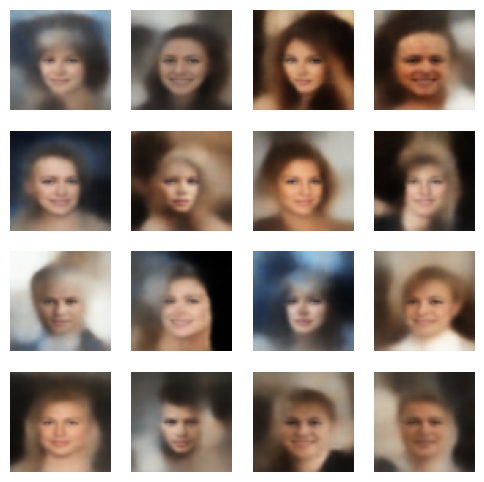

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def plot_generated_images(decoder,n=16):

    latent_vectors = np.random.normal(size=(n,LATENT_DIM))

    generated = decoder.predict(latent_vectors)

    plt.figure(figsize=(6,6))

    for i in range(n):
        plt.subplot(4,4,i+1)
        plt.imshow(generated[i])
        plt.axis("off")

    plt.show()

plot_generated_images(decoder)